# Overfitting et correction

In [53]:
import copy

import numpy as np
import plotnine as pn
import polars as pl
import torch
from torch import nn
from torchinfo import summary

from adl import cooking

pn.theme_set(pn.theme_minimal())

Dans ce tp nous allons aborder plus en profondeur le concept d'overfitting que l'on a pu aborder vaguement dans les tp précédent. 

Pour illustrer ce concept, imaginons que nous demandions à plusieurs personnes de goûter
et d'évaluer une recette de gâteau, en faisant varier le temps de cuisson de 5 à
120 minutes.

Voici un exemple d'ensemble de données généré à partir de 30 évaluations basées sur le temps de cuisson

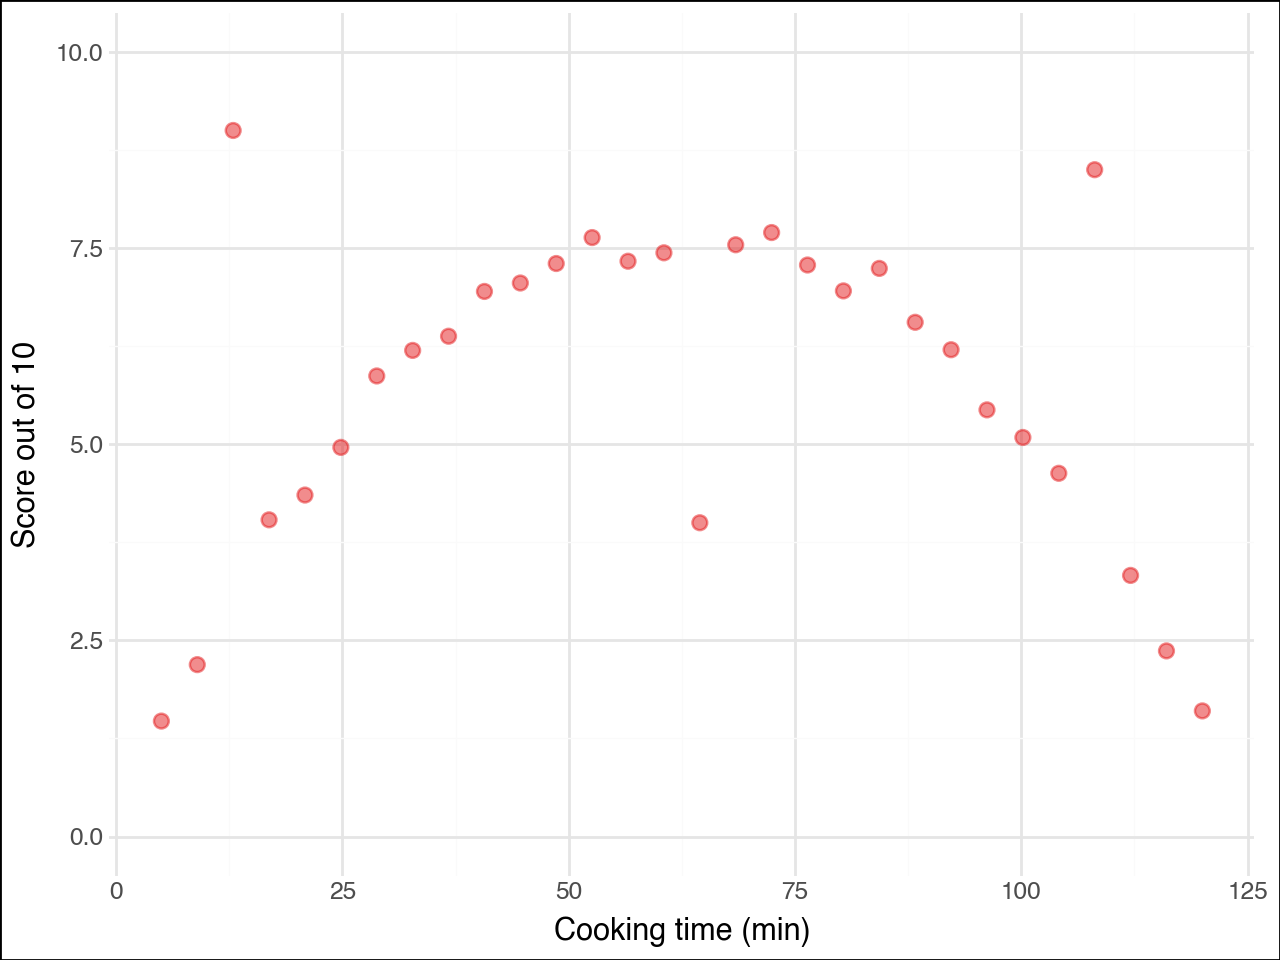

In [54]:
# Generate random data
np.random.seed(42)
time, score = cooking.generate_data(size=30)
# Add some outliers
score[[2, 15, 26]] = torch.tensor([[9], [4], [8.5]])

# Plot data
cooking.scatter_plot(time, score)

Dans ce graphique, chaque point représente une note associée à un temps de cuisson.
On constate que globalement, les données semblent suivre une distribution parabolique,
mais qu'il existe 3 valeurs aberrantes (introduites intentionnellement).

Nous allons entraîner un réseau neuronal dense sur ce petit ensemble de données afin d'essayer de
prédire la note à partir de la valeur du temps de cuisson.

Nous créons d'abord une classe de réseau et un objet modèle.

In [55]:
class RegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=1, out_features=100),
            nn.Sigmoid(),
            nn.Linear(in_features=100, out_features=100),
            nn.Sigmoid(),
            nn.Linear(in_features=100, out_features=1),
        )

    def forward(self, x):
        # Center data
        x = x - 115 / 2 # cela nous permet de mieux centrer les 
                        #données et d'améliorer l'apprentissage
        return self.model(x)


model = RegressionNetwork()
print(summary(model))

Layer (type:depth-idx)                   Param #
RegressionNetwork                        --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       200
│    └─Sigmoid: 2-2                      --
│    └─Linear: 2-3                       10,100
│    └─Sigmoid: 2-4                      --
│    └─Linear: 2-5                       101
Total params: 10,401
Trainable params: 10,401
Non-trainable params: 0


Ce réseau dense possède 2 couches linéaire de 100 variables. Ce qui représente 10 000 paramètres, ce qui est bien trop pour notre jeu de données.

In [56]:
# Model training step
def train_step(x, y, model, loss_fn, optimizer):
    # Set the model to training mode
    model.train()
    # Reset gradients
    optimizer.zero_grad()
    # Forward pass: compute predicted values
    y_pred = model(x)
    # Compute loss
    loss = loss_fn(y_pred, y)
    # Backpropagations
    loss.backward()
    # Parameters adjustment
    optimizer.step()
    return loss


# Loss function
loss_fn = nn.MSELoss()
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005)

# Run training
epochs = 2000
for epoch in range(epochs):
    loss = train_step(time, score, model, loss_fn, optimizer)
    if (epoch + 1) % 500 == 0:
        print(f"{epoch + 1:5}. loss: {loss:5.3f}")

  500. loss: 2.305
 1000. loss: 1.684
 1500. loss: 0.863
 2000. loss: 0.188


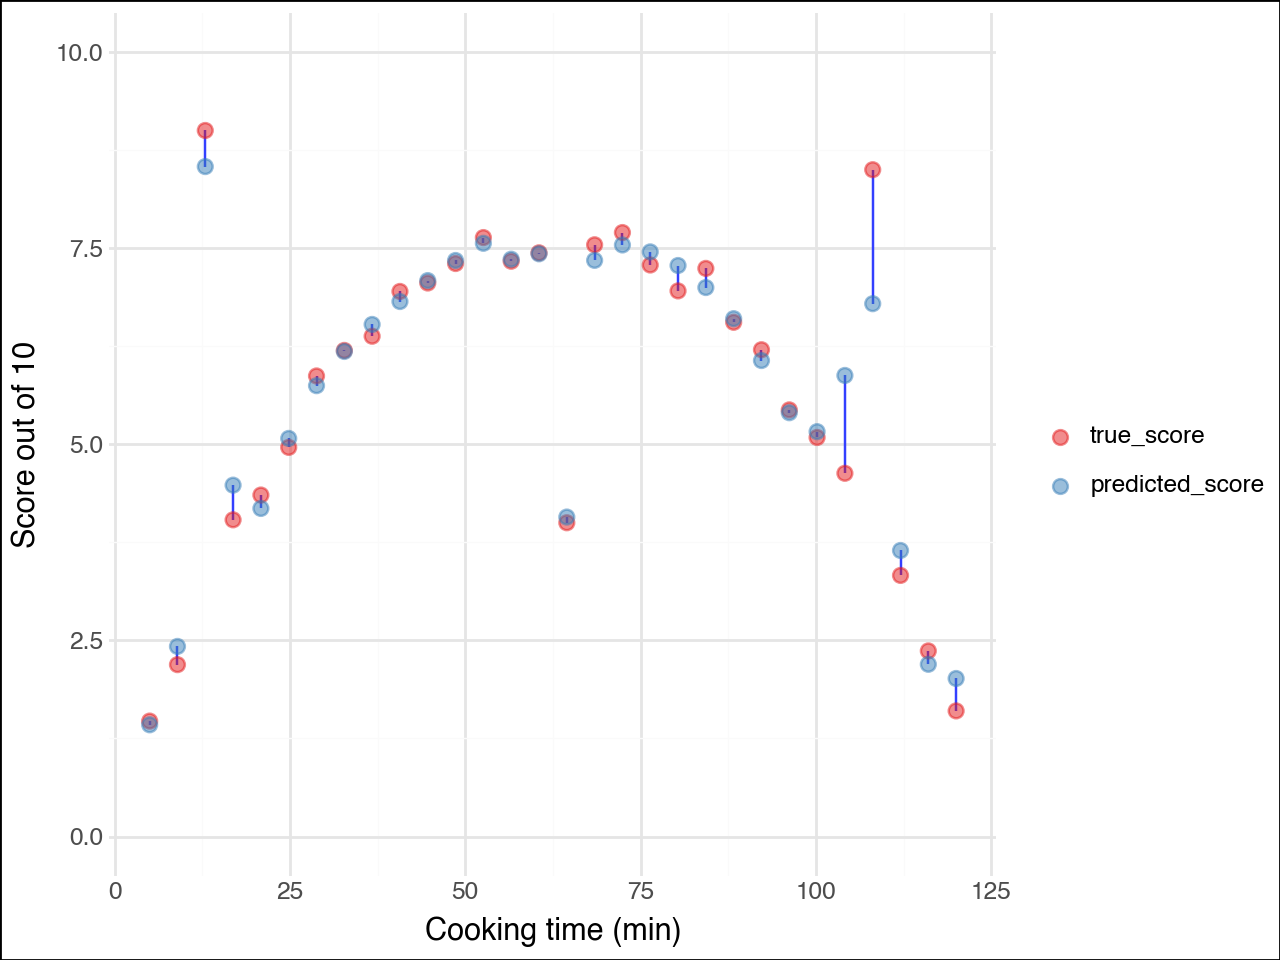

In [57]:
score_pred = model(time)
cooking.scatter_plot_pred(time, score, score_pred)

On remarque que le modèle prédit bien les données même les valeurs extrêmes.

Supposons que nous avons de nouvelles données sans outliers. En appliquant notre modèle on pourra prédire les scores et comparer.

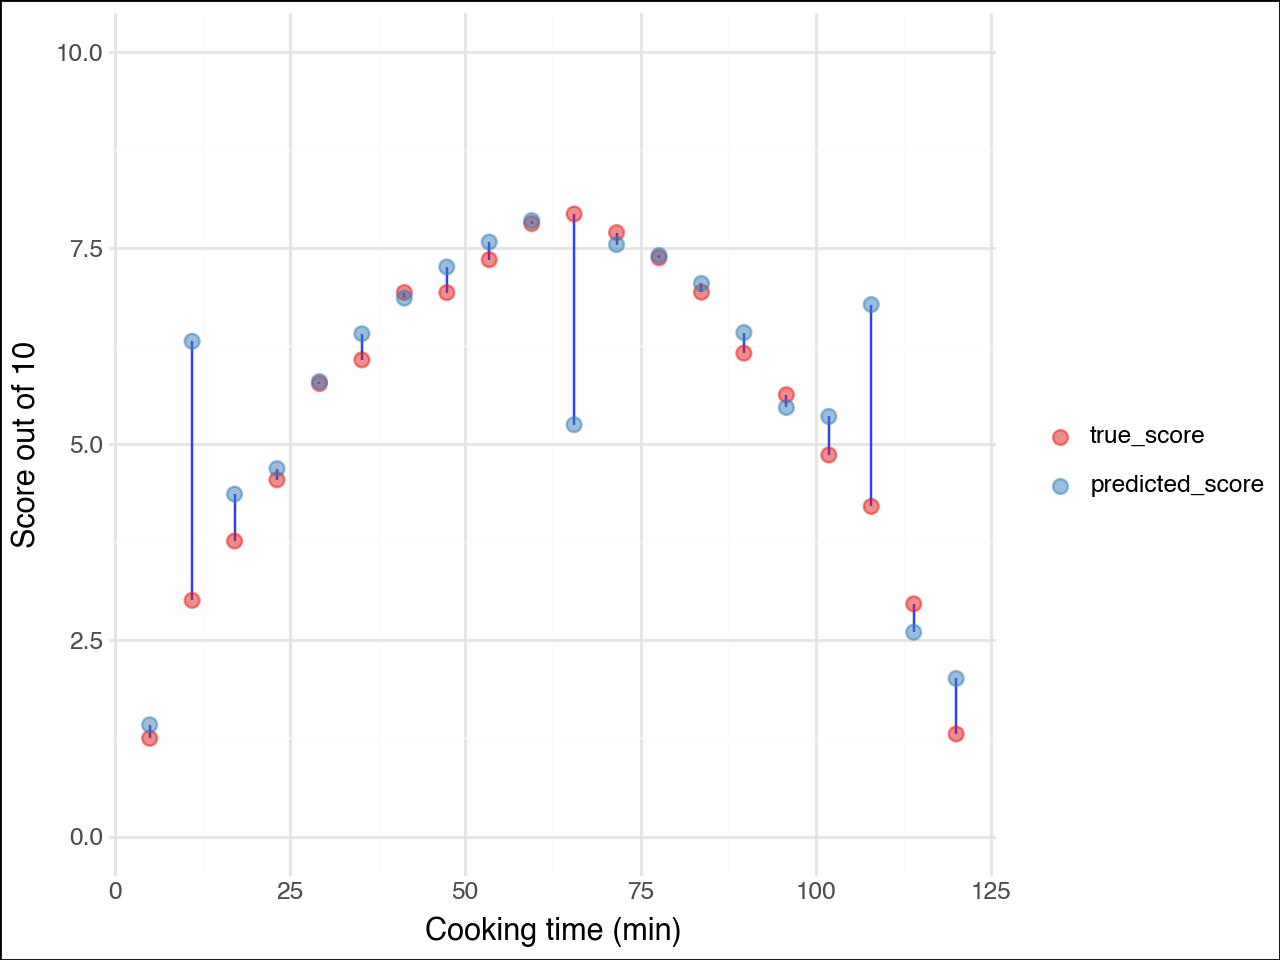

In [58]:
# Generate new data
time_new, score_new = cooking.generate_data(size=20)

# Compute and plot predicted scores vs true scores
score_new_pred = model(time_new)
cooking.scatter_plot_pred(time_new, score_new, score_new_pred)

On voit bien ici que notre modèle garde le même parttern que les données précédentes, cela signifie que a trop appris des précédentes données et n'est plus capable de généraliser.

# Validation des données

Une manière de limiter l'overfitting est de diviser notre jeu de données en deux parties : une partie d'entraînement et une partie de test. Le modèle sera entraîné sur les données d'entraînement mais à chaque epoch on calculera la loss des deux jeu de données (test et train).

In [59]:
time_valid, score_valid = cooking.generate_data(size=20)

print(time_valid, score_valid)

tensor([[  5.0000],
        [ 11.0526],
        [ 17.1053],
        [ 23.1579],
        [ 29.2105],
        [ 35.2632],
        [ 41.3158],
        [ 47.3684],
        [ 53.4211],
        [ 59.4737],
        [ 65.5263],
        [ 71.5789],
        [ 77.6316],
        [ 83.6842],
        [ 89.7368],
        [ 95.7895],
        [101.8421],
        [107.8947],
        [113.9474],
        [120.0000]]) tensor([[1.4373],
        [2.5635],
        [3.6340],
        [4.8813],
        [5.8155],
        [6.5068],
        [6.7247],
        [7.2634],
        [7.6851],
        [7.9683],
        [7.6925],
        [7.6271],
        [7.1797],
        [6.7592],
        [6.6192],
        [6.0470],
        [4.9413],
        [4.1970],
        [2.9701],
        [1.5310]])


On va modifier notre code pour calcluler la loss sur les données de validation a chaque epoch après que les paramètres soient ajustés.

In [60]:
def train_step_with_validation(x, y, x_valid, y_valid, model, loss_fn, optimizer):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    loss.backward()
    optimizer.step()

    # Compute validation loss
    model.eval()
    valid_pred = model(x_valid)
    valid_loss = loss_fn(valid_pred, y_valid)

    return loss, valid_loss

In [61]:
model = RegressionNetwork()

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005)

results = []

epochs = 2000

for epoch in range(epochs):
    loss, valid_loss = train_step_with_validation(
        time, score, time_valid, score_valid, model, loss_fn, optimizer
    )
    if (epoch + 1) % 200 == 0:
        print(f"{epoch + 1:5}. loss: {loss:5.3f}, valid_loss: {valid_loss:5.3f}")
    if (epoch + 1) % 10 == 0:
        results.append({"epoch": epoch + 1, "loss": loss, "valid_loss": valid_loss})

  200. loss: 3.327, valid_loss: 2.844
  400. loss: 2.317, valid_loss: 1.116
  600. loss: 2.073, valid_loss: 0.825
  800. loss: 1.868, valid_loss: 0.633
 1000. loss: 1.642, valid_loss: 0.568
 1200. loss: 1.225, valid_loss: 0.639
 1400. loss: 0.914, valid_loss: 0.919
 1600. loss: 0.504, valid_loss: 1.186
 1800. loss: 0.159, valid_loss: 1.452
 2000. loss: 0.050, valid_loss: 1.582


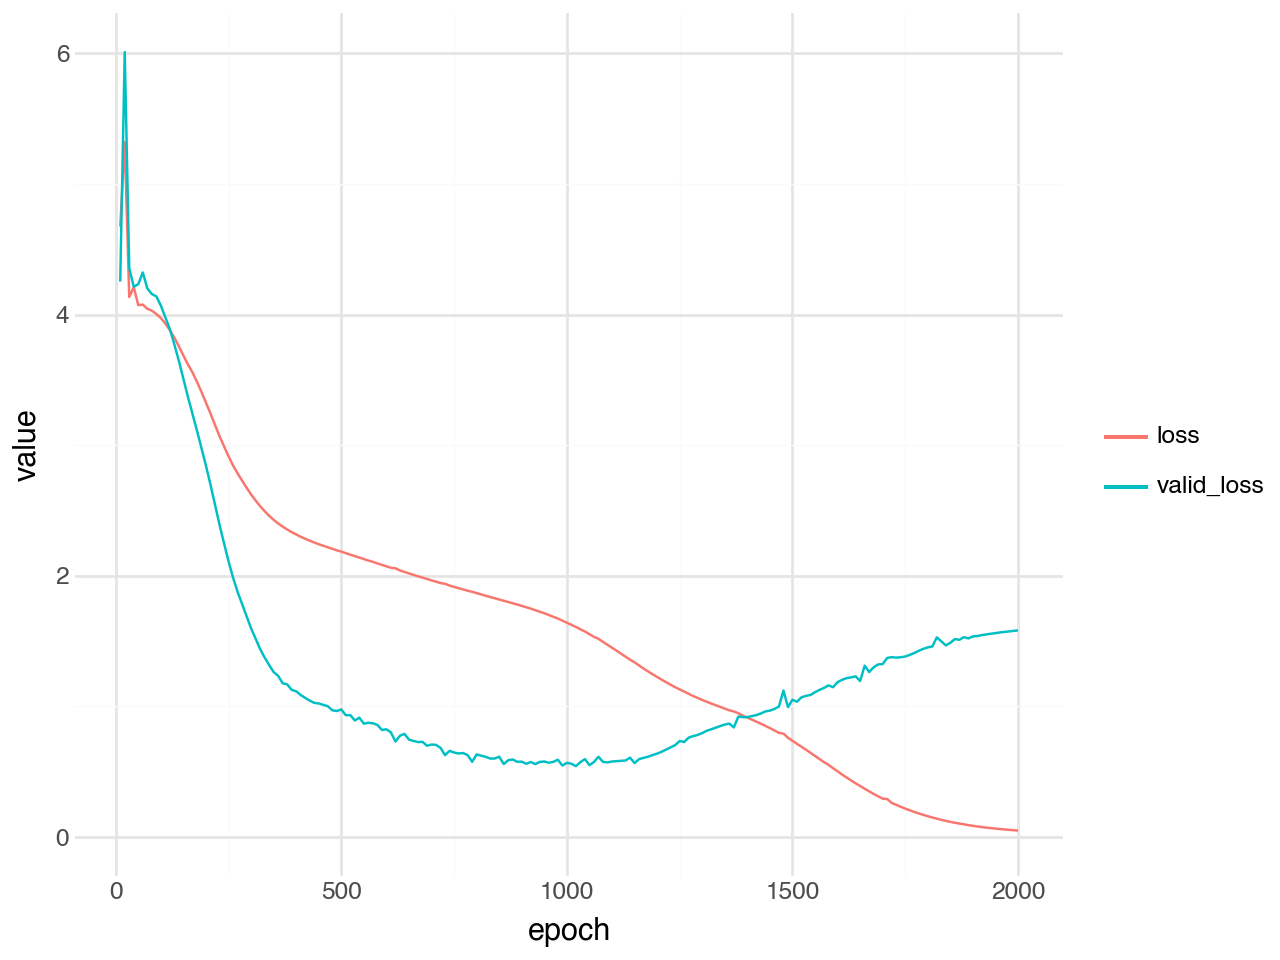

In [62]:
d = pl.DataFrame(results).unpivot(index="epoch", on=["loss", "valid_loss"])

(
    pn.ggplot(d, pn.aes(x="epoch", y="value", color="variable"))
    + pn.geom_line()
    + pn.scale_y_continuous(limits=[0, None])  # type: ignore
    + pn.labs(color="")
)

Ce graphique nous permet de voir que jusqu'à environs 100 epoch les deux loss descendent rapidement. Ensuite, leur évolution est inversée. On voit que la loss d'entraînement continue de descendre contrairement à la loss de validation qui remonte.

Pour expliquer ce phénomène, on peut dire que le modèle apprends correctement (en faisant le moins d'erreur possible) jusqu'à environs 1000 epochs, ensuite la remonté de la loss sur le jeu de donnée de test signifie que le modèle n'arrive plus à généraliser les données et commence à apprendre par coeur les données d'entraînement.


En utilisant à la fois un ensemble de données d'entraînement et un ensemble de données de validation et en surveillant leur perte à chaque époque, il est possible de déterminer si et quand la perte de validation commence à augmenter. Si cela se produit, cela indique un
surajustement, ce qui suggère que l'entraînement devrait être interrompu vers l' époque correspondante.

Une bonne façon de procéder consiste à suivre la perte de validation à chaque
époque et à enregistrer le modèle correspondant à la perte de validation la plus faible
atteinte pendant le processus d'entraînement.

Le code suivant montre comment procéder.

In [63]:
model = RegressionNetwork() 

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005)

best_model = copy.deepcopy(model.state_dict())
best_loss = np.inf
best_epoch = None

epochs = 2000

for epoch in range(epochs):
    loss, valid_loss = train_step_with_validation(
        time, score, time_valid, score_valid, model, loss_fn, optimizer
    )
    if valid_loss < best_loss:
        best_loss = valid_loss
        best_model = copy.deepcopy(model)
        best_epoch = epoch

    # Print progress
    if (epoch + 1) % 200 == 0:
        print(f"{epoch + 1:5}. loss: {loss:5.3f}, valid_loss: {valid_loss:5.3f}")

print(f"\nBest validation loss: {best_loss:.3f}, reached at epoch {best_epoch}")

  200. loss: 3.606, valid_loss: 3.409
  400. loss: 2.357, valid_loss: 1.194
  600. loss: 2.101, valid_loss: 0.940
  800. loss: 1.871, valid_loss: 0.640
 1000. loss: 1.603, valid_loss: 0.587
 1200. loss: 1.193, valid_loss: 0.688
 1400. loss: 0.924, valid_loss: 0.948
 1600. loss: 0.565, valid_loss: 1.142
 1800. loss: 0.255, valid_loss: 1.340
 2000. loss: 0.100, valid_loss: 1.553

Best validation loss: 0.527, reached at epoch 993


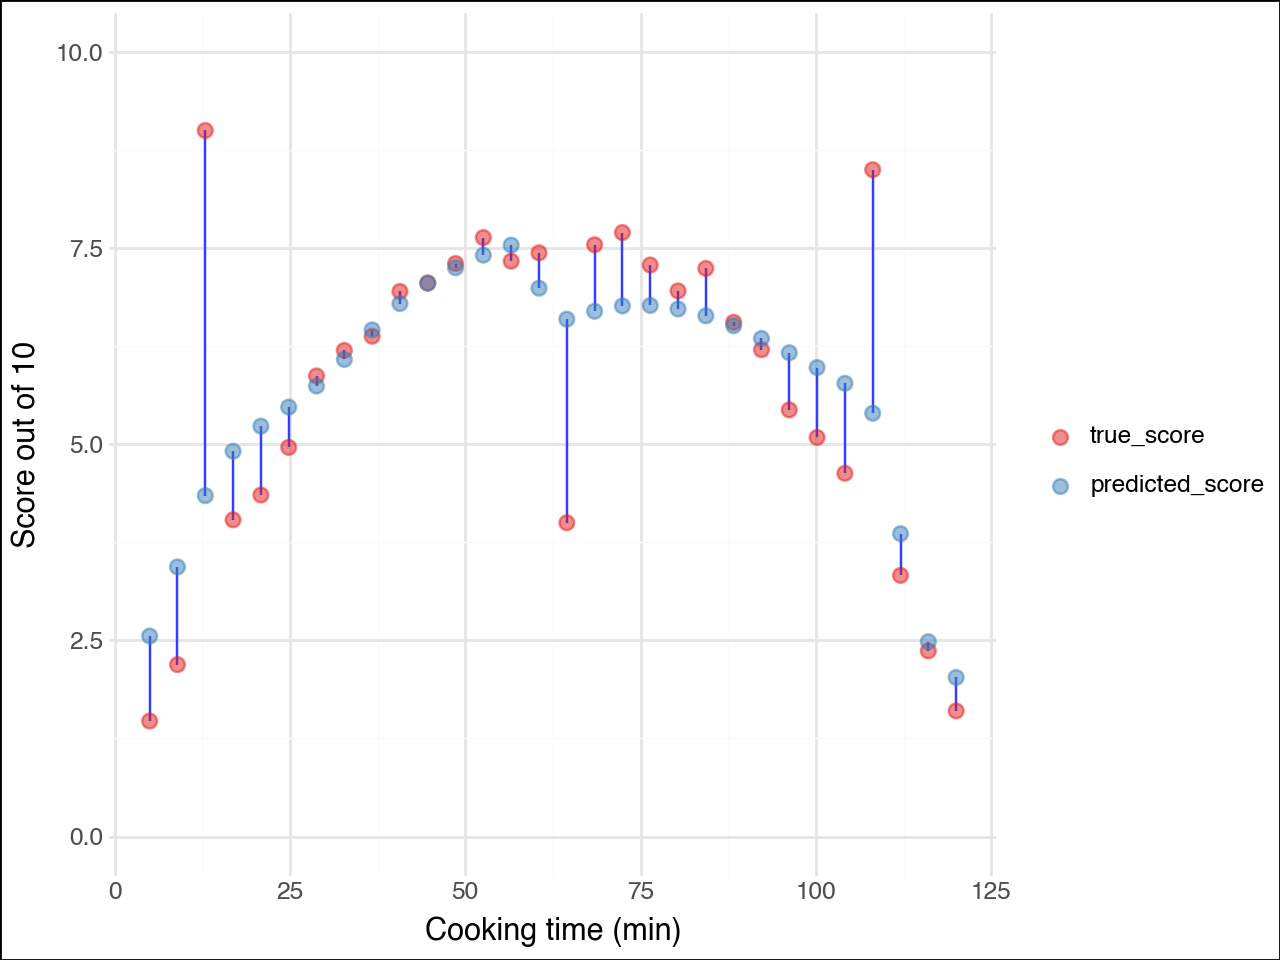

In [64]:
best_model(time)

cooking.scatter_plot_pred(time, score, best_model(time))

# Donnée de test 

Utiliser un jeu de donnée de validation est bien, mais il est encore possible que notre modèle overfit les données de validation. 

Imaginez qu'on lance l'entraînement un grand nombre de fois, que l'on modifie l'architecture du réseau ou que l'on utilisé différent optimizers etc.


Au cours de chaque processus d'entraînement, nous utiliserons notre ensemble de données de validation pour évaluer la qualité de nos résultats. Ce faisant, nous avons tendance à ajuster nos
hyperparamètres et l'architecture du réseau à cet ensemble de données de validation, ce qui peut conduire à une forme de surajustement et dégrader la capacité de généralisation du modèle.

Pour éviter cela, nous pouvons ajouter un troisième ensemble de données, appelé ensemble de données *test*. Ce sont les données qui seront utilisées pour calculer la qualité finale
de nos résultats.

**Exercice**

Générez un petit ensemble de données test de taille 20 et calculez la perte sur cet
ensemble de données test sur notre meilleur modèle calculé précédemment.

## Points à retenir

En résumé, nos données d'entraînement (étiquetées) peuvent être divisées en trois
ensembles de données :

-   l'ensemble de données *train* est utilisé pour entraîner le modèle et ajuster ses
    paramètres
-   l'ensemble de données *validation* est utilisé pour évaluer la perte à la fin de
    chaque époque et éviter le surajustement en sélectionnant le meilleur modèle en fonction
    de cette perte de validation
-   l'ensemble de données *test* est utilisé à la fin de tous les processus de réglage et d'
    entraînement du modèle pour évaluer la qualité finale de ses résultats sur la base de
    données jamais vues auparavant

Idéalement, l'ensemble de données test ne devrait être utilisé qu'une seule fois. Cela est
parfois difficile dans la pratique, mais dans tous les cas, il devrait être utilisé (et
vu par le modèle) aussi rarement que possible.

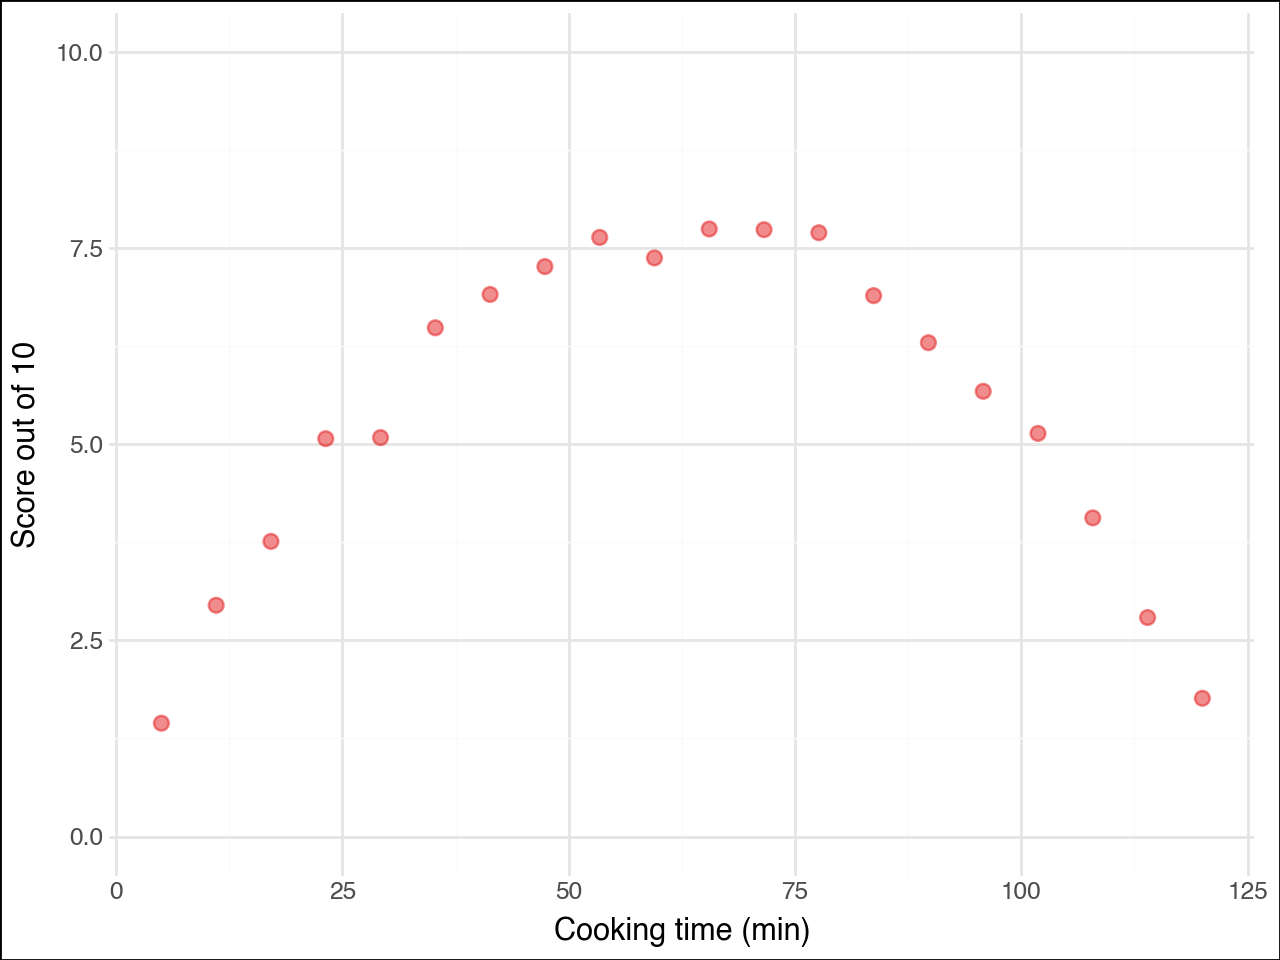

In [65]:
time , score = cooking.generate_data(size=20)

cooking.scatter_plot(time, score)

In [ ]:
# Final model evaluation on test data
best_model.eval()
test_pred = best_model(time)
test_loss = loss_fn(test_pred, score)

print(f"Loss on test data: {test_loss:.3f}")

Loss on test data: 0.514
